# Assignment 2 CPSC 542

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from pathlib import Path
from sklearn.preprocessing import MultiLabelBinarizer
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision import models
from tqdm import tqdm


/usr/local/lib/python3.12/dist-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.stats import gaussian_kde


## Pipeline Development
Anna Harner

1) Start by mapping indexes from meta data to images to create the labels for our images

We have 12 subfolders of images that are not sorted in any way by disease, in order to put the labels on the images correlating to each disease we need to map the correlating disease with image index from the metadata to each image.

In [2]:
MetaData = pd.read_csv('Chest_XRay+Data/Data_Entry_2017.csv')
MetaData.head()

# We can see that image index correlates to a specific png in a subfolder

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [3]:
# Create a dictionary with key = filename and value = path to image
image_path_dict = {os.path.basename(x): x for x in 
                   Path('Chest_XRay+Data').glob('images_*/images/*.png')}

# Create a new column in the dataframe that maps the image index to the path
MetaData['path'] = MetaData['Image Index'].map(image_path_dict)
MetaData.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,path
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN,Chest_XRay+Data/images_001/images/00000001_000...
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN,Chest_XRay+Data/images_001/images/00000001_001...
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN,Chest_XRay+Data/images_001/images/00000001_002...
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,Chest_XRay+Data/images_001/images/00000002_000...
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN,Chest_XRay+Data/images_001/images/00000003_000...


In [4]:
# Check for missing images
missing_count = MetaData['path'].isnull().sum()
print(f"Missing images: {missing_count}")

Missing images: 0


Now we need to one hot encode the Finding Labels to use them in our model later on.

In [5]:
# One hot encode the Finding labels and add those binary columns back into the dataframe
MetaData['Finding Labels'] = MetaData['Finding Labels'].map(lambda x: x.split('|'))

mlb = MultiLabelBinarizer()
label_masks = mlb.fit_transform(MetaData['Finding Labels'])
label_names = mlb.classes_

# Add these binary columns back to the main dataframe
MetaData_Final = pd.concat([MetaData, pd.DataFrame(label_masks, columns=label_names)], axis=1)

print(f"Dataset ready with {len(label_names)} classes.")
print(MetaData_Final[['Image Index', 'Finding Labels', 'path']].head())

Dataset ready with 15 classes.
        Image Index             Finding Labels  \
0  00000001_000.png             [Cardiomegaly]   
1  00000001_001.png  [Cardiomegaly, Emphysema]   
2  00000001_002.png   [Cardiomegaly, Effusion]   
3  00000002_000.png               [No Finding]   
4  00000003_000.png                   [Hernia]   

                                                path  
0  Chest_XRay+Data/images_001/images/00000001_000...  
1  Chest_XRay+Data/images_001/images/00000001_001...  
2  Chest_XRay+Data/images_001/images/00000001_002...  
3  Chest_XRay+Data/images_001/images/00000002_000...  
4  Chest_XRay+Data/images_001/images/00000003_000...  


In [6]:
MetaData_Final.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,...,Emphysema,Fibrosis,Hernia,Infiltration,Mass,No Finding,Nodule,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000001_000.png,[Cardiomegaly],0,1,58,M,PA,2682,2749,0.143,...,0,0,0,0,0,0,0,0,0,0
1,00000001_001.png,"[Cardiomegaly, Emphysema]",1,1,58,M,PA,2894,2729,0.143,...,1,0,0,0,0,0,0,0,0,0
2,00000001_002.png,"[Cardiomegaly, Effusion]",2,1,58,M,PA,2500,2048,0.168,...,0,0,0,0,0,0,0,0,0,0
3,00000002_000.png,[No Finding],0,2,81,M,PA,2500,2048,0.171,...,0,0,0,0,0,1,0,0,0,0
4,00000003_000.png,[Hernia],0,3,81,F,PA,2582,2991,0.143,...,0,0,1,0,0,0,0,0,0,0


Since our iamges are vyer large, we need to resize them, however since medical images rely on detail we are doing it with Lanczos interpolation which uses a mathematical formula (a sinc function) to look at a 8×8 neighborhood of pixels around the target destination. It calculates a weighted average that prevents "aliasing"—those jagged, stair-step lines you see in low-quality images.

Why we used it for X-rays:

    Edge Preservation: X-rays rely on seeing sharp edges (like the edge of a lung or a rib fracture). Lanczos maintains these edges better than other methods.

    Texture Detail: Diseases like "Infiltration" or "Emphysema" appear as subtle textures. Standard resizing can "smear" these textures, making them invisible to the AI.

Then we choes 512x512 as our target .

We also do augmentation here by flipping the image hroizontally only during training, we are opposed to doing other types of augmentation as medical image data can be sensitive.

In [7]:
# 1. SETUP CONSTANTS
TARGET_SIZE = 512 

# 2. THE DATASET CLASS
class NIHChestXrayDataset(Dataset):
    def __init__(self, dataframe, target_size=512, split="train"):
        """
        Args:
            dataframe: Your master MetaData_Final dataframe
            target_size: The resolution to resize to
            split: "train" for augmentation, "val"/"test" to skip it
        """
        self.df = dataframe.copy()
        self.target_size = target_size
        self.split = split  # Fixed: Added this to store the split type
        
        # Identify the 15 columns (14 diseases + 1 No Finding)
        # Assuming these are the last 15 columns created by your MultiLabelBinarizer
        self.labels = self.df.iloc[:, -15:].values 
        
        # Populate metadata columns as requested
        self.df['adjusted_height'] = target_size
        self.df['adjusted_width'] = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # A. Load Path
        img_path = str(self.df.iloc[idx]['path'])
        
        # B. Load Image
        image = cv2.imread(img_path)
        if image is None:
            raise FileNotFoundError(f"OpenCV could not find: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # C. Resize Engine (Lanczos4 for medical quality)
        image = cv2.resize(image, (self.target_size, self.target_size), 
                           interpolation=cv2.INTER_LANCZOS4)

        # D. AUGMENTATION
        # Horizontal flip helps the model generalize without losing medical meaning
        if self.split == "train":
            if np.random.random() > 0.5:
                image = np.fliplr(image).copy() 

        # E. Normalization (Converts 0-255 to ImageNet-standard float range)
        image = image.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = (image - mean) / std

        # F. To Tensor (Channels, Height, Width)
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return image, label

# 3. INITIALIZE 
# Initializing with split="train" to enable the augmentation logic
full_dataset = NIHChestXrayDataset(MetaData_Final, target_size=TARGET_SIZE, split="train")

# 4. VERIFY THE PIPELINE
sample_img, sample_lbl = full_dataset[0]

print("--- PIPELINE VERIFICATION ---")
print(f"Target Size constant: {TARGET_SIZE}")
print(f"Actual Tensor shape (C, H, W): {sample_img.shape}") 
print(f"Label vector size: {len(sample_lbl)} (Includes 'No Finding')")
print(f"Metadata height record: {full_dataset.df.iloc[0]['adjusted_height']}px")

if sample_img.shape[1] == TARGET_SIZE:
    print("\n✅ SUCCESS: Image resized and split logic initialized correctly.")
else:
    print("\n❌ ERROR: Dimension mismatch.")

--- PIPELINE VERIFICATION ---
Target Size constant: 512
Actual Tensor shape (C, H, W): torch.Size([3, 512, 512])
Label vector size: 15 (Includes 'No Finding')
Metadata height record: 512px

✅ SUCCESS: Image resized and split logic initialized correctly.


The previous block essentially:
Lanczos4 Resizing: You aren't just shrinking pixels; you're using a high-quality interpolation method that preserves the fine edges needed for X-ray diagnosis.

Normalization: This centers your data, which is essential for the CNN and ViT models to converge during training.

On-the-fly Augmentation: By flipping images in __getitem__, you effectively double your dataset size in the eyes of the model without using extra disk space.

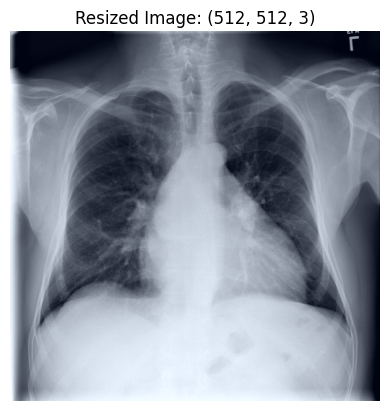

In [8]:
import matplotlib.pyplot as plt

# Get the image and convert from (C, H, W) to (H, W, C) for plotting
# Also 'un-normalize' the image roughly to see it clearly
img_to_show = sample_img.permute(1, 2, 0).numpy()
img_to_show = (img_to_show * 0.229) + 0.485 # Reverse normalization
img_to_show = np.clip(img_to_show, 0, 1)

plt.imshow(img_to_show)
plt.title(f"Resized Image: {img_to_show.shape}")
plt.axis('off')
plt.show()

Finally after preparing our data we can create our train, validation and testing sets. The dataset we are using provided a train_val_list and test_list, so we are using those and further splitting train_val_list into separate training and validation sets by patient ID to prevent any leakage. 

In [9]:
import numpy as np

# 1. Load the official NIH lists
with open('Chest_XRay+Data/train_val_list.txt', 'r') as f:
    train_val_list = [line.strip() for line in f]

with open('Chest_XRay+Data/test_list.txt', 'r') as f:
    test_list = [line.strip() for line in f]

# 2. Filter the master dataframe into 'Train_Val' and 'Test'
train_val_df_raw = MetaData_Final[MetaData_Final['Image Index'].isin(train_val_list)]
test_df = MetaData_Final[MetaData_Final['Image Index'].isin(test_list)]

# 3. Create a clean Validation set (Split Train_Val by Patient ID)
# This prevents 'Data Leakage'
unique_patients = train_val_df_raw['Patient ID'].unique()
np.random.seed(42) # For consistency
np.random.shuffle(unique_patients)

# 80/20 split of the train_val patients
split_idx = int(0.8 * len(unique_patients))
train_pts = unique_patients[:split_idx]
val_pts = unique_patients[split_idx:]

train_df = train_val_df_raw[train_val_df_raw['Patient ID'].isin(train_pts)]
val_df = train_val_df_raw[train_val_df_raw['Patient ID'].isin(val_pts)]

print(f"✅ Pipeline Splits Complete:")
print(f"Training images: {len(train_df)} (from {len(train_pts)} patients)")
print(f"Validation images: {len(val_df)} (from {len(val_pts)} patients)")
print(f"Testing images: {len(test_df)}")

✅ Pipeline Splits Complete:
Training images: 68918 (from 22406 patients)
Validation images: 17606 (from 5602 patients)
Testing images: 25596


A test to verify the pipeline works before continueing with oru real models

In [10]:
# Just test 2 batches to see if it finishes
small_train_subset = torch.utils.data.Subset(train_df, range(32)) 
train_loader = DataLoader(small_train_subset, batch_size=16, shuffle=True)

In [ ]:


def get_medical_model(architecture='cnn', num_classes=15):
    """
    Task 3: Basic Model Pipeline
    Supports DenseNet-121 (CNN) and ViT-B/16
    """
    if architecture == 'cnn':
        # Initialize DenseNet-121 without pre-trained weights for Task 3
        model = models.densenet121(weights=None)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)
        
    elif architecture == 'vit':
        # Initialize ViT without pre-trained weights for Task 3
        model = models.vit_b_16(weights=None)
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, num_classes)
        
    return model

In [16]:
def run_epoch(model, loader, criterion, optimizer, device, phase='train'):
    if phase == 'train':
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    pbar = tqdm(loader, desc=f"{phase.capitalize()} Phase")
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Track history only if in train phase
        with torch.set_grad_enabled(phase == 'train'):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            if phase == 'train':
                loss.backward()
                optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        pbar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

In [ ]:

# 1. Reset indices (Crucial to fix the KeyError)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# A. Setup Hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# B. Initialize Datasets FIRST, then DataLoaders
# We wrap the dataframes in the NIHChestXrayDataset class you built
train_dataset = NIHChestXrayDataset(train_df, target_size=TARGET_SIZE, split="train")
val_dataset = NIHChestXrayDataset(val_df, target_size=TARGET_SIZE, split="val")

train_loader = DataLoader(
    train_dataset,        # Changed from train_df to train_dataset
    batch_size=16, 
    shuffle=True, 
    num_workers=8,      
    pin_memory=True,    
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,          # Changed from val_df to val_dataset
    batch_size=16, 
    shuffle=False,        # Usually False for validation
    num_workers=8,      
    pin_memory=True,    
    prefetch_factor=2
)

# C. Initialize Model, Loss, and Optimizer
model = get_medical_model(architecture='cnn', num_classes=15).to(device)
criterion = nn.BCEWithLogitsLoss() 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# D. Run 1 Epoch to verify Task 3 Pipeline
print("Starting Task 3 Pipeline Verification...")
train_loss = run_epoch(model, train_loader, criterion, optimizer, device, phase='train')
val_loss = run_epoch(model, val_loader, criterion, optimizer, device, phase='val')

print(f"\n--- TASK 3 PIPELINE VERIFIED ---")
print(f"Train Loss: {train_loss:.4f}")
print(f"Val Loss: {val_loss:.4f}")

Starting Task 3 Pipeline Verification...


In [ ]:
# 1. Setup Hardware
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize the FULL Dataset objects first (This satisfies the .copy() requirement)
full_train_dataset = NIHChestXrayDataset(train_df, target_size=TARGET_SIZE, split="train")
full_val_dataset = NIHChestXrayDataset(val_df, target_size=TARGET_SIZE, split="val")

# 3. Create "Small" versions for the Task 3 Verification (using Subset)
# This takes the first 32 samples of the dataset
small_train_subset = torch.utils.data.Subset(full_train_dataset, range(32))
small_val_subset = torch.utils.data.Subset(full_val_dataset, range(32))

# 4. Initialize DataLoaders using the subsets
# Setting num_workers=0 and pin_memory=False for this quick test to avoid server lag
train_loader = DataLoader(small_train_subset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(small_val_subset, batch_size=16, shuffle=False, num_workers=0)

# 5. Initialize Model, Loss, and Optimizer
model = get_medical_model(architecture='cnn', num_classes=15).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# 6. Run the Verification
print("Starting Task 3 Pipeline Verification (Small Subset)...")
train_loss = run_epoch(model, train_loader, criterion, optimizer, device, phase='train')
val_loss = run_epoch(model, val_loader, criterion, optimizer, device, phase='val')

print(f"\n--- TASK 3 PIPELINE VERIFIED ---")
print(f"Train Loss: {train_loss:.4f}")
print(f"Val Loss: {val_loss:.4f}")

Starting Task 3 Pipeline Verification (Small Subset)...


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
Val Phase:   0%|          | 0/2 [00:01<?, ?it/s, loss=0.709]


--- TASK 3 PIPELINE VERIFIED ---
Train Loss: 0.6907
Val Loss: 0.7106


## Transfer Learning Pipeline (Task 4)
Marissa Estramonte

Scenarios (c) and (d): pretrained DenseNet-121 and ViT-B/16 with two-phase training.
- **Phase 1** — frozen backbone, train head only (3–5 epochs, head stabilizes fast)
- **Phase 2** — unfreeze all layers, fine-tune with 10× lower LR on backbone

Three helper functions:
1. `get_transfer_model()` — loads ImageNet weights, freezes/unfreezes backbone for the requested phase
2. `build_optimizer()` — Adam with differential LRs (backbone: `head_lr/10`, head: `head_lr`)
3. `evaluate_metrics()` — per-class and macro AUC-ROC on any DataLoader

In [ ]:
from torchvision.models import DenseNet121_Weights, ViT_B_16_Weights

def get_transfer_model(architecture='cnn', num_classes=15, phase=1):
    """
    Creates a pretrained model configured for two-phase transfer learning.
    Scenarios (c) and (d) only — use get_medical_model() for from-scratch training.

    Phase 1: backbone frozen, only the new classification head is trainable.
    Phase 2: all layers unfrozen for fine-tuning (use with build_optimizer phase=2).

    Args:
        architecture: 'cnn' (DenseNet-121) or 'vit' (ViT-B/16)
        num_classes:  number of output classes (15 for NIH)
        phase:        1 (frozen backbone) or 2 (all layers trainable)

    Returns:
        model ready for the requested phase
    """
    if architecture == 'cnn':
        model = models.densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
        num_ftrs = model.classifier.in_features
        model.classifier = nn.Linear(num_ftrs, num_classes)  # new head, requires_grad=True

        if phase == 1:
            for param in model.features.parameters():
                param.requires_grad = False
        else:  # phase 2
            for param in model.parameters():
                param.requires_grad = True

    elif architecture == 'vit':
        model = models.vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        num_ftrs = model.heads.head.in_features
        model.heads.head = nn.Linear(num_ftrs, num_classes)  # new head, requires_grad=True

        if phase == 1:
            for name, param in model.named_parameters():
                if 'heads' not in name:
                    param.requires_grad = False
        else:  # phase 2
            for param in model.parameters():
                param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"[{architecture.upper()} Phase {phase}] Trainable: {trainable:,} / {total:,} "
          f"({100 * trainable / total:.1f}%)")

    return model

In [ ]:
def build_optimizer(model, architecture, phase, head_lr=1e-4):
    """
    Creates an Adam optimizer with differential learning rates for two-phase training.

    Phase 1: only the classification head is optimized (backbone is frozen).
    Phase 2: backbone gets head_lr/10, head keeps head_lr.

    Args:
        model:        the transfer learning model
        architecture: 'cnn' or 'vit' (identifies head vs backbone params)
        phase:        1 or 2
        head_lr:      learning rate for the classification head (default 1e-4)

    Returns:
        torch.optim.Adam optimizer
    """
    backbone_lr = head_lr / 10  # 10x lower for pretrained layers

    if architecture == 'cnn':
        head_params     = list(model.classifier.parameters())
        backbone_params = list(model.features.parameters())
    elif architecture == 'vit':
        head_params     = list(model.heads.parameters())
        backbone_params = [p for n, p in model.named_parameters() if 'heads' not in n]

    if phase == 1:
        optimizer = torch.optim.Adam(head_params, lr=head_lr)
        print(f"Phase 1 optimizer: head only  |  lr={head_lr}")
    elif phase == 2:
        optimizer = torch.optim.Adam([
            {'params': backbone_params, 'lr': backbone_lr},
            {'params': head_params,     'lr': head_lr},
        ])
        print(f"Phase 2 optimizer: backbone lr={backbone_lr}  |  head lr={head_lr}")

    return optimizer

In [ ]:
from sklearn.metrics import roc_auc_score

def evaluate_metrics(model, loader, device, label_names):
    """
    Runs inference on a DataLoader and computes per-class AUC-ROC.

    Args:
        model:       trained model
        loader:      DataLoader (val or test)
        device:      torch device
        label_names: list of class name strings, length == num_classes

    Returns:
        per_class_auc: dict {class_name: auc_score}
        macro_auc:     float, mean AUC across all valid classes
    """
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs  = inputs.to(device)
            outputs = model(inputs)
            probs   = torch.sigmoid(outputs).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())

    all_probs  = np.vstack(all_probs)   # (N, num_classes)
    all_labels = np.vstack(all_labels)  # (N, num_classes)

    per_class_auc = {}
    for i, name in enumerate(label_names):
        # AUC is undefined when only one class is present in the batch
        if len(np.unique(all_labels[:, i])) < 2:
            per_class_auc[name] = float('nan')
        else:
            per_class_auc[name] = roc_auc_score(all_labels[:, i], all_probs[:, i])

    valid_aucs = [v for v in per_class_auc.values() if not np.isnan(v)]
    macro_auc  = float(np.mean(valid_aucs))

    print("\n--- Per-Class AUC-ROC ---")
    for name, auc in per_class_auc.items():
        if np.isnan(auc):
            print(f"  {name:<22}: N/A (single class in split)")
        else:
            print(f"  {name:<22}: {auc:.4f}")
    print(f"\n  Macro AUC: {macro_auc:.4f}")

    return per_class_auc, macro_auc

### Scenario (c) & (d): Two-Phase Training Functions

Both scenarios share the same training logic via `_run_transfer_training()`:
- **Phase 1** always runs the full `phase1_epochs` — head-only training converges fast and 3–5 epochs is already minimal
- **Phase 2** uses early stopping (patience=7) and `ReduceLROnPlateau` on macro AUC
- Phase 1 checkpoint is loaded into the Phase 2 model before fine-tuning begins
- Returns a `results` dict with per-epoch losses/AUCs and best checkpoint paths for visualization

In [ ]:
def _run_transfer_training(architecture, train_loader, val_loader, device, label_names,
                           phase1_epochs=5, phase2_epochs=20, head_lr=1e-4,
                           checkpoint_dir='checkpoints'):
    """
    Shared two-phase transfer learning loop for scenarios (c) and (d).

    Phase 1: frozen backbone, train head only for the full phase1_epochs (no early stopping).
    Phase 2: all layers unfrozen, fine-tune with differential LRs, early stopping on macro AUC.

    Args:
        architecture:    'cnn' or 'vit'
        train_loader:    training DataLoader
        val_loader:      validation DataLoader
        device:          torch device
        label_names:     list of class name strings (mlb.classes_)
        phase1_epochs:   number of head-only epochs (default 5)
        phase2_epochs:   max fine-tuning epochs (default 20)
        head_lr:         learning rate for head; backbone gets head_lr/10 in Phase 2
        checkpoint_dir:  directory to save .pth checkpoints

    Returns:
        results dict with phase1 and phase2 losses, AUCs, and checkpoint paths
    """
    os.makedirs(checkpoint_dir, exist_ok=True)
    criterion = nn.BCEWithLogitsLoss()
    results   = {}

    # ------------------------------------------------------------------
    # PHASE 1: frozen backbone, train head only
    # ------------------------------------------------------------------
    print(f"\n{'='*55}")
    print(f"  PHASE 1 | {architecture.upper()} | Frozen Backbone | {phase1_epochs} epochs")
    print(f"{'='*55}")

    model     = get_transfer_model(architecture, num_classes=15, phase=1).to(device)
    optimizer = build_optimizer(model, architecture, phase=1, head_lr=head_lr)

    p1_losses, p1_aucs = [], []

    for epoch in range(1, phase1_epochs + 1):
        train_loss          = run_epoch(model, train_loader, criterion, optimizer, device, phase='train')
        val_loss            = run_epoch(model, val_loader,   criterion, optimizer, device, phase='val')
        per_class_auc, macro_auc = evaluate_metrics(model, val_loader, device, label_names)

        p1_losses.append({'train': train_loss, 'val': val_loss})
        p1_aucs.append(macro_auc)
        print(f"  Epoch {epoch}/{phase1_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Macro AUC: {macro_auc:.4f}")

    p1_ckpt = os.path.join(checkpoint_dir, f'{architecture}_phase1.pth')
    torch.save(model.state_dict(), p1_ckpt)
    print(f"\n  Phase 1 checkpoint saved -> {p1_ckpt}")

    results['phase1'] = {
        'losses':          p1_losses,
        'aucs':            p1_aucs,
        'final_macro_auc': p1_aucs[-1],
        'checkpoint':      p1_ckpt,
    }

    # ------------------------------------------------------------------
    # PHASE 2: unfreeze all layers, fine-tune with differential LRs
    # ------------------------------------------------------------------
    print(f"\n{'='*55}")
    print(f"  PHASE 2 | {architecture.upper()} | Full Fine-Tune  | up to {phase2_epochs} epochs")
    print(f"{'='*55}")

    # Load Phase 1 weights before unfreezing — this is the key step
    model = get_transfer_model(architecture, num_classes=15, phase=2).to(device)
    model.load_state_dict(torch.load(p1_ckpt, map_location=device))

    optimizer = build_optimizer(model, architecture, phase=2, head_lr=head_lr)
    # ReduceLROnPlateau watches macro AUC (higher = better)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=3, factor=0.5, verbose=True
    )

    p2_losses, p2_aucs = [], []
    best_auc            = 0.0
    best_epoch          = 0
    patience_counter    = 0
    early_stop_patience = 7
    p2_best_ckpt        = os.path.join(checkpoint_dir, f'{architecture}_phase2_best.pth')

    for epoch in range(1, phase2_epochs + 1):
        train_loss               = run_epoch(model, train_loader, criterion, optimizer, device, phase='train')
        val_loss                 = run_epoch(model, val_loader,   criterion, optimizer, device, phase='val')
        per_class_auc, macro_auc = evaluate_metrics(model, val_loader, device, label_names)

        scheduler.step(macro_auc)
        p2_losses.append({'train': train_loss, 'val': val_loss})
        p2_aucs.append(macro_auc)

        if macro_auc > best_auc:
            best_auc, best_epoch = macro_auc, epoch
            patience_counter     = 0
            torch.save(model.state_dict(), p2_best_ckpt)
            marker = "  <-- best"
        else:
            patience_counter += 1
            marker = f"  (patience {patience_counter}/{early_stop_patience})"

        print(f"  Epoch {epoch}/{phase2_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Macro AUC: {macro_auc:.4f}{marker}")

        if patience_counter >= early_stop_patience:
            print(f"\n  Early stop: no AUC improvement for {early_stop_patience} epochs.")
            break

    results['phase2'] = {
        'losses':         p2_losses,
        'aucs':           p2_aucs,
        'best_macro_auc': best_auc,
        'best_epoch':     best_epoch,
        'checkpoint':     p2_best_ckpt,
    }

    # ------------------------------------------------------------------
    # Summary
    # ------------------------------------------------------------------
    print(f"\n{'='*55}")
    print(f"  RESULTS SUMMARY: {architecture.upper()}")
    print(f"{'='*55}")
    print(f"  Phase 1  Final Macro AUC : {results['phase1']['final_macro_auc']:.4f}  (epoch {phase1_epochs})")
    print(f"  Phase 2  Best  Macro AUC : {results['phase2']['best_macro_auc']:.4f}  (epoch {best_epoch})")
    print(f"  Best checkpoint          : {p2_best_ckpt}")

    return results


def train_scenario_c(train_loader, val_loader, device, label_names,
                     phase1_epochs=5, phase2_epochs=20, head_lr=1e-4,
                     checkpoint_dir='checkpoints'):
    """Scenario (c): DenseNet-121 with ImageNet pretraining, two-phase transfer learning."""
    print("\nSCENARIO (c): DenseNet-121 Transfer Learning")
    return _run_transfer_training('cnn', train_loader, val_loader, device, label_names,
                                  phase1_epochs, phase2_epochs, head_lr, checkpoint_dir)


def train_scenario_d(train_loader, val_loader, device, label_names,
                     phase1_epochs=5, phase2_epochs=20, head_lr=1e-4,
                     checkpoint_dir='checkpoints'):
    """Scenario (d): ViT-B/16 with ImageNet pretraining, two-phase transfer learning."""
    print("\nSCENARIO (d): ViT-B/16 Transfer Learning")
    return _run_transfer_training('vit', train_loader, val_loader, device, label_names,
                                  phase1_epochs, phase2_epochs, head_lr, checkpoint_dir)

### Scenario (a) & (b): From-Scratch Training Functions

Single-phase training using Anna's `get_medical_model()` (no pretrained weights) and `run_epoch()`.
Early stopping watches **val loss** (not AUC) — from-scratch training is noisier early on, so loss is a more stable signal than AUC in the first several epochs.

In [ ]:
def _run_scratch_training(architecture, train_loader, val_loader, device, label_names,
                          num_epochs=20, lr=1e-4, checkpoint_dir='checkpoints'):
    """
    Shared from-scratch training loop for scenarios (a) and (b).

    Single-phase training with no pretrained weights. Early stopping on val loss.

    Args:
        architecture:    'cnn' (DenseNet-121) or 'vit' (ViT-B/16)
        train_loader:    training DataLoader
        val_loader:      validation DataLoader
        device:          torch device
        label_names:     list of class name strings (mlb.classes_)
        num_epochs:      max training epochs (default 20)
        lr:              learning rate for all layers (default 1e-4)
        checkpoint_dir:  directory to save .pth checkpoints

    Returns:
        results dict with per-epoch losses, AUCs, best checkpoint path
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    model     = get_medical_model(architecture=architecture, num_classes=15).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # ReduceLROnPlateau watches val loss (lower = better)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5, verbose=True
    )

    losses           = []
    aucs             = []
    best_val_loss    = float('inf')
    best_epoch       = 0
    patience_counter = 0
    early_stop_patience = 5
    best_ckpt        = os.path.join(checkpoint_dir, f'{architecture}_scratch_best.pth')

    print(f"\n{'='*55}")
    print(f"  FROM SCRATCH | {architecture.upper()} | up to {num_epochs} epochs")
    print(f"{'='*55}")

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"  Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.1f}%)\n")

    for epoch in range(1, num_epochs + 1):
        train_loss               = run_epoch(model, train_loader, criterion, optimizer, device, phase='train')
        val_loss                 = run_epoch(model, val_loader,   criterion, optimizer, device, phase='val')
        per_class_auc, macro_auc = evaluate_metrics(model, val_loader, device, label_names)

        scheduler.step(val_loss)
        losses.append({'train': train_loss, 'val': val_loss})
        aucs.append(macro_auc)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_epoch       = epoch
            patience_counter = 0
            torch.save(model.state_dict(), best_ckpt)
            marker = "  <-- best"
        else:
            patience_counter += 1
            marker = f"  (patience {patience_counter}/{early_stop_patience})"

        print(f"  Epoch {epoch}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Macro AUC: {macro_auc:.4f}{marker}")

        if patience_counter >= early_stop_patience:
            print(f"\n  Early stop: val loss did not improve for {early_stop_patience} epochs.")
            break

    print(f"\n{'='*55}")
    print(f"  RESULTS SUMMARY: {architecture.upper()} (from scratch)")
    print(f"{'='*55}")
    print(f"  Best Val Loss  : {best_val_loss:.4f}  (epoch {best_epoch})")
    print(f"  AUC at best    : {aucs[best_epoch - 1]:.4f}")
    print(f"  Best checkpoint: {best_ckpt}")

    return {
        'losses':         losses,
        'aucs':           aucs,
        'best_val_loss':  best_val_loss,
        'best_macro_auc': aucs[best_epoch - 1],
        'best_epoch':     best_epoch,
        'checkpoint':     best_ckpt,
    }


def train_scenario_a(train_loader, val_loader, device, label_names,
                     num_epochs=20, lr=1e-4, checkpoint_dir='checkpoints'):
    """Scenario (a): DenseNet-121 trained from scratch (no pretrained weights)."""
    print("\nSCENARIO (a): DenseNet-121 From Scratch")
    return _run_scratch_training('cnn', train_loader, val_loader, device, label_names,
                                 num_epochs, lr, checkpoint_dir)


def train_scenario_b(train_loader, val_loader, device, label_names,
                     num_epochs=20, lr=1e-4, checkpoint_dir='checkpoints'):
    """Scenario (b): ViT-B/16 trained from scratch (no pretrained weights)."""
    print("\nSCENARIO (b): ViT-B/16 From Scratch")
    return _run_scratch_training('vit', train_loader, val_loader, device, label_names,
                                 num_epochs, lr, checkpoint_dir)

## Results Visualization (Step 6)

Three functions comparing all four scenarios:
1. `plot_comparison_table()` — printed summary + saved PNG table
2. `plot_loss_curves()` — train/val loss per scenario; Phase 1 / Phase 2 split shown for (c) and (d)
3. `plot_auc_comparison()` — macro AUC bar chart across all scenarios

Call `visualize_all()` to run all three at once.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# ------------------------------------------------------------------
# Internal helper: normalize both dict structures to a common format
# ------------------------------------------------------------------
def _normalize(results, scenario):
    """
    Returns a flat dict regardless of whether results came from
    _run_scratch_training (a/b) or _run_transfer_training (c/d).

    Keys always present:
      losses         list of {'train': float, 'val': float}  (all epochs)
      aucs           list of macro AUC floats                 (all epochs)
      best_epoch     epoch index of best checkpoint (1-based, relative to phase2 for c/d)
      best_macro_auc macro AUC at best checkpoint
      best_val_loss  lowest val loss seen
      phase1_auc     Phase 1 final AUC, or None for (a)/(b)
      phase1_len     number of Phase 1 epochs, or 0 for (a)/(b)
    """
    if scenario in ('a', 'b'):
        return {
            'losses':         results['losses'],
            'aucs':           results['aucs'],
            'best_epoch':     results['best_epoch'],
            'best_macro_auc': results['best_macro_auc'],
            'best_val_loss':  results['best_val_loss'],
            'phase1_auc':     None,
            'phase1_len':     0,
        }
    else:  # c / d
        p1, p2 = results['phase1'], results['phase2']
        return {
            'losses':         p1['losses'] + p2['losses'],
            'aucs':           p1['aucs']   + p2['aucs'],
            'best_epoch':     len(p1['losses']) + p2['best_epoch'],  # global epoch number
            'best_macro_auc': p2['best_macro_auc'],
            'best_val_loss':  min(l['val'] for l in p2['losses']),
            'phase1_auc':     p1['final_macro_auc'],
            'phase1_len':     len(p1['losses']),
        }


# ------------------------------------------------------------------
# 1. Comparison table
# ------------------------------------------------------------------
def plot_comparison_table(results_a, results_b, results_c, results_d,
                          save_path='comparison_table.png'):
    """
    Prints a summary table and saves it as a PNG.
    For (c) and (d), shows Phase 1 AUC -> Phase 2 AUC to highlight transfer benefit.
    """
    labels   = ['(a) CNN scratch', '(b) ViT scratch',
                 '(c) CNN pretrained', '(d) ViT pretrained']
    raw      = [results_a, results_b, results_c, results_d]
    scenarios = ['a', 'b', 'c', 'd']
    normed   = [_normalize(r, s) for r, s in zip(raw, scenarios)]

    rows = []
    for label, n in zip(labels, normed):
        auc_progression = (f"{n['phase1_auc']:.4f} -> {n['best_macro_auc']:.4f}"
                           if n['phase1_auc'] is not None
                           else f"{n['best_macro_auc']:.4f}")
        rows.append({
            'Scenario':        label,
            'Best Epoch':      n['best_epoch'],
            'Best Val Loss':   f"{n['best_val_loss']:.4f}",
            'Phase 1 AUC':     f"{n['phase1_auc']:.4f}" if n['phase1_auc'] else '—',
            'Best Macro AUC':  f"{n['best_macro_auc']:.4f}",
            'AUC Progression': auc_progression,
        })

    df = pd.DataFrame(rows)

    # Print to console
    print("\n" + "="*75)
    print("  RESULTS COMPARISON — ALL SCENARIOS")
    print("="*75)
    print(df.to_string(index=False))
    print("="*75)

    # Save as PNG table
    fig, ax = plt.subplots(figsize=(13, 2.2))
    ax.axis('off')
    col_labels = list(df.columns)
    cell_text  = df.values.tolist()

    tbl = ax.table(cellText=cell_text, colLabels=col_labels,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.6)

    # Shade header row
    for j in range(len(col_labels)):
        tbl[0, j].set_facecolor('#2c3e50')
        tbl[0, j].set_text_props(color='white', fontweight='bold')

    # Highlight the best macro AUC row
    best_idx = max(range(len(normed)), key=lambda i: normed[i]['best_macro_auc'])
    for j in range(len(col_labels)):
        tbl[best_idx + 1, j].set_facecolor('#d5f5e3')  # light green

    plt.title('Scenario Comparison — NIH Chest X-ray Multi-Label Classification',
              fontsize=11, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {save_path}")


# ------------------------------------------------------------------
# 2. Loss curves
# ------------------------------------------------------------------
def plot_loss_curves(results_a, results_b, results_c, results_d,
                     save_path='loss_curves.png'):
    """
    2x2 grid of train/val loss curves, one subplot per scenario.
    For (c) and (d): Phase 1 region is shaded and the boundary is marked.
    """
    labels   = ['(a) DenseNet-121 Scratch', '(b) ViT-B/16 Scratch',
                 '(c) DenseNet-121 Pretrained', '(d) ViT-B/16 Pretrained']
    raw      = [results_a, results_b, results_c, results_d]
    scenarios = ['a', 'b', 'c', 'd']
    normed   = [_normalize(r, s) for r, s in zip(raw, scenarios)]

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for ax, label, n in zip(axes, labels, normed):
        epochs     = list(range(1, len(n['losses']) + 1))
        train_loss = [l['train'] for l in n['losses']]
        val_loss   = [l['val']   for l in n['losses']]

        ax.plot(epochs, train_loss, label='Train Loss', color='#2980b9', linewidth=1.8)
        ax.plot(epochs, val_loss,   label='Val Loss',   color='#e74c3c', linewidth=1.8)

        # Phase 1 shading for transfer learning scenarios
        if n['phase1_len'] > 0:
            ax.axvspan(1, n['phase1_len'], alpha=0.12, color='orange',
                       label=f"Phase 1 ({n['phase1_len']} epochs)")
            ax.axvline(x=n['phase1_len'], color='orange', linestyle='--',
                       linewidth=1.2, label='Phase 1 -> 2')

        # Mark best epoch
        ax.axvline(x=n['best_epoch'], color='#27ae60', linestyle=':',
                   linewidth=1.5, label=f"Best (ep {n['best_epoch']})")

        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('BCE Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle('Training & Validation Loss — All Scenarios',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {save_path}")


# ------------------------------------------------------------------
# 3. AUC comparison bar chart
# ------------------------------------------------------------------
def plot_auc_comparison(results_a, results_b, results_c, results_d,
                        save_path='auc_comparison.png'):
    """
    Grouped bar chart comparing macro AUC across all four scenarios.
    For (c) and (d), also shows Phase 1 AUC as a lighter bar to illustrate
    the transfer learning improvement.
    """
    labels   = ['(a)\nCNN\nScratch', '(b)\nViT\nScratch',
                 '(c)\nCNN\nPretrained', '(d)\nViT\nPretrained']
    raw      = [results_a, results_b, results_c, results_d]
    scenarios = ['a', 'b', 'c', 'd']
    normed   = [_normalize(r, s) for r, s in zip(raw, scenarios)]

    final_aucs  = [n['best_macro_auc'] for n in normed]
    phase1_aucs = [n['phase1_auc'] if n['phase1_auc'] else None for n in normed]

    # Color by architecture (CNN = blue family, ViT = red family)
    bar_colors = ['#2980b9', '#c0392b', '#1a5276', '#7b241c']
    x = range(len(labels))

    fig, ax = plt.subplots(figsize=(10, 6))

    bars = ax.bar(x, final_aucs, color=bar_colors, width=0.5,
                  zorder=3, label='Best Macro AUC (Phase 2 for c/d)')

    # Overlay Phase 1 AUC as a lighter hatched bar for (c) and (d)
    for i, p1_auc in enumerate(phase1_aucs):
        if p1_auc is not None:
            ax.bar(i, p1_auc, color=bar_colors[i], width=0.5,
                   alpha=0.35, hatch='//', zorder=4,
                   label='Phase 1 AUC' if i == 2 else '')

    # Value labels on bars
    for bar, auc in zip(bars, final_aucs):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{auc:.4f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    # Mark best scenario
    best_idx = final_aucs.index(max(final_aucs))
    ax.annotate('Best', xy=(best_idx, final_aucs[best_idx]),
                xytext=(best_idx, final_aucs[best_idx] + 0.025),
                ha='center', fontsize=10, color='#27ae60', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#27ae60'))

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Macro AUC-ROC', fontsize=11)
    ax.set_ylim(0, min(1.0, max(final_aucs) + 0.08))
    ax.set_title('Macro AUC-ROC Comparison — All Scenarios\n'
                 'Hatched bars show Phase 1 (head-only) AUC for transfer learning models',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.legend(fontsize=9)

    # Architecture legend patches
    cnn_patch = mpatches.Patch(color='#2980b9', label='CNN (DenseNet-121)')
    vit_patch = mpatches.Patch(color='#c0392b', label='ViT-B/16')
    ax.legend(handles=[cnn_patch, vit_patch,
                        mpatches.Patch(facecolor='grey', alpha=0.4, hatch='//',
                                       label='Phase 1 AUC (transfer only)')],
              loc='lower right', fontsize=9)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {save_path}")


# ------------------------------------------------------------------
# Convenience wrapper
# ------------------------------------------------------------------
def visualize_all(results_a, results_b, results_c, results_d):
    """Run all three visualization functions and save all PNGs."""
    plot_comparison_table(results_a, results_b, results_c, results_d)
    plot_loss_curves(      results_a, results_b, results_c, results_d)
    plot_auc_comparison(   results_a, results_b, results_c, results_d)

In [ ]:
results_a = train_scenario_a(train_loader, val_loader, device, label_names=list(label_names))
results_b = train_scenario_b(train_loader, val_loader, device, label_names=list(label_names))
results_c = train_scenario_c(train_loader, val_loader, device, label_names=list(label_names))
results_d = train_scenario_d(train_loader, val_loader, device, label_names=list(label_names))

visualize_all(results_a, results_b, results_c, results_d)